# Lesson 1A 

In this class we will learn how to work with networks in R:

- Creating networks: manually and from files
- Saving networks: formats 

## Introduction to graphs in R

In this course we will work with networks using a small set of key R libraries. 

We will use **igraph** as the main tool to create and analyse networks, since it allows us to work with graphs, compute network metrics, and apply different algorithms. 

Data manipulation will be done using the **tidyverse**, which makes it easier to handle tables associated with networks. 

For visualisation, we will use **ggraph**, which allows flexible and clear network representations.
 
In addition, for ecological networks such as plant–pollinator systems, we will also use specialised packages like **bipartite**, designed specifically for the analysis of these types of networks.


### Importing the required libraries


In [5]:
# If needed (run once):
# install.packages(c("igraph","tidyverse","tidygraph","ggraph"))

library(igraph)
library(tidyverse)
library(tidygraph)
library(ggraph)
library(bipartite)

source("Functions.R") #include some helpers


## Creating simple graphs
**igraph** offers many ways to create a graph. The simplest one is the function `make_empty_graph()`:

In [140]:
g <- make_empty_graph()

To add one or more vertices to an existing graph, use `add_vertices()`

In [30]:
g <- add_vertices(g, 37) 

#Note: If you try to add edges to vertices with invalid IDs (i.e., you try to add an edge to vertex 38 when the graph has only 37 vertices), 
#igraph shows an error:

Similarly, to add vertices you can use `add_edges()`. Edges are added by specifying the source and target vertex IDs for each edge. This call added three edges, one connecting vertices 1 and 35, one connecting vertices 1 and 36, and one connecting vertices 34 and 37.

In [31]:
g <- add_edges(g, edges = c(1,35, 1,36, 34,37))

The most common way to create a graph is make_graph(), which constructs a network based on specified edges. For example, to make an undirected graph with 5 nodes (numbered 1 to 5) and 4 edges:

In [141]:
# from list of edges (it assumes n=maximum value of elements in )
EdgeList1 <- c(1,2, 1,3, 2,3, 3,5)
g1 <- make_graph(edges=EdgeList1, directed=FALSE)
g1$name <- "Example network" #we name the network

We can print the graph to get a summary of its nodes and edges:

In [142]:
g1

IGRAPH 144cccf U--- 5 4 -- Example network
+ attr: name (g/c)
+ edges from 144cccf:
[1] 1--2 1--3 2--3 3--5

This means: Undirected graph with 5 vertices and 4 edges, with the exact edges listed out. If the graph has a [name] attribute, it is printed as well.

We can retrieve the nodes(vertices) as `V(g)` and the links(edges) as `E(g)`, to iterate trouhg them.

In [143]:
print(V(g1))
print(E(g1))

+ 5/5 vertices, from 144cccf:
[1] 1 2 3 4 5
+ 4/4 edges from 144cccf:
[1] 1--2 1--3 2--3 3--5


And the general information with summary

In [144]:
print(class(g1))
summary(g1)

[1] "igraph"
IGRAPH 144cccf U--- 5 4 -- Example network
+ attr: name (g/c)


We can visualize the network with `plot(g)`

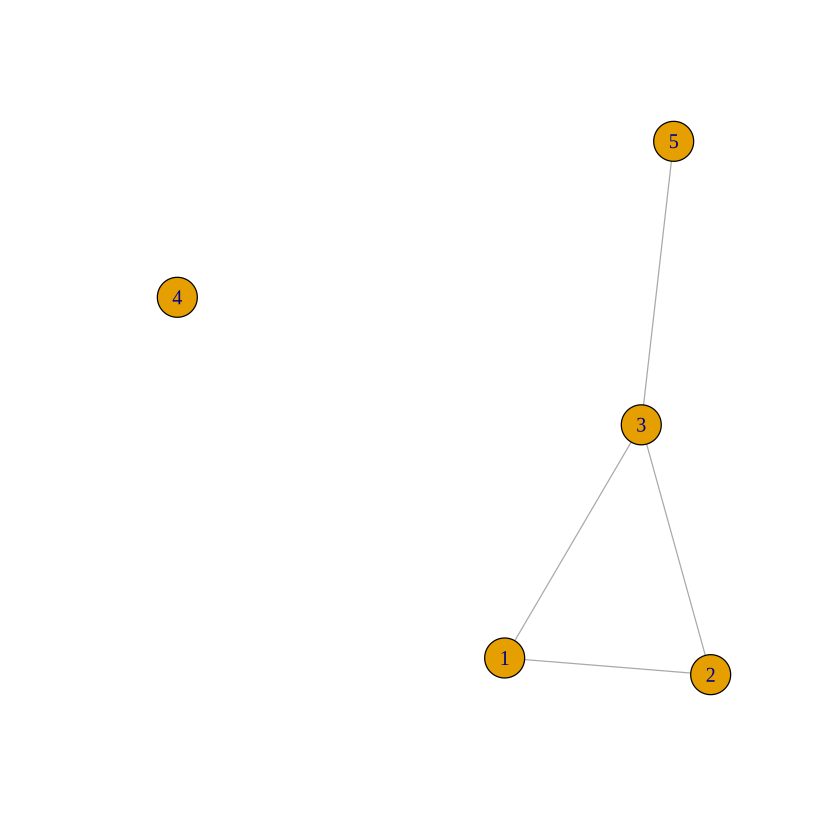

In [145]:
plot(g1)

There are many optional arguments to the draw function to customize the appearance.

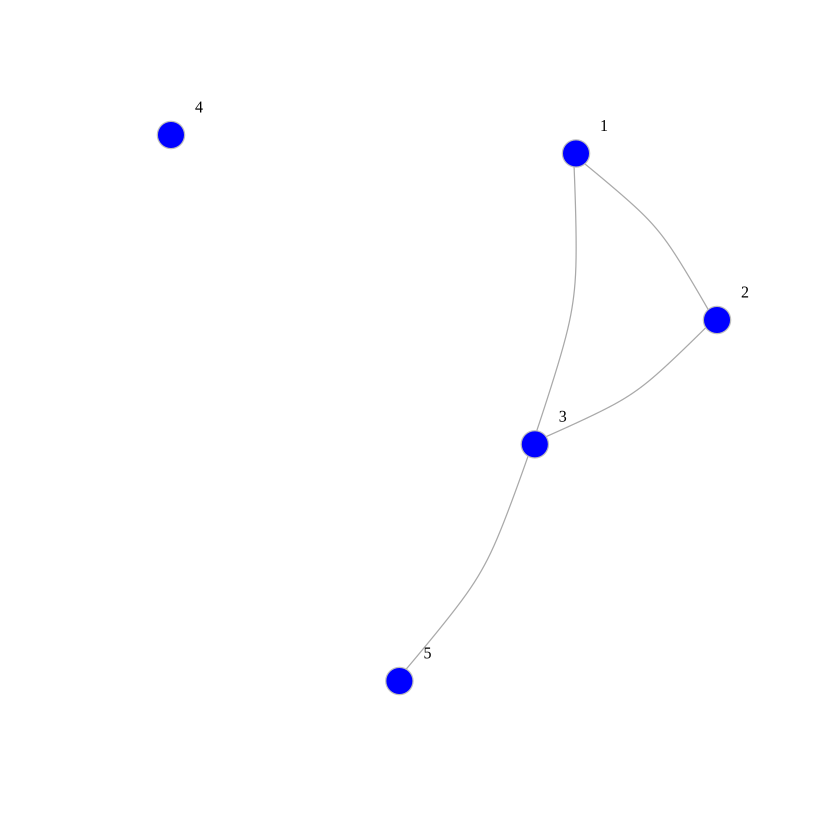

In [37]:
plot(g1, vertex.color="blue", vertex.size=10, 

     vertex.frame.color="gray", vertex.label.color="black", 

     vertex.label.cex=0.8, vertex.label.dist=2, edge.curved=0.2) 


<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 1</h3>
Create the undirected graph corresponding to this simple network

![title](./images/figure1.png)
</div>

In [38]:
# write your code here and run it ################
#g2<-

```r
 EdgeList1 <- c(1,2, 2,3, 3,4, 3,5)
g2 <- graph(edges=EdgeList1, directed=FALSE)
plot(g2,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",vertex.size=20) 
```

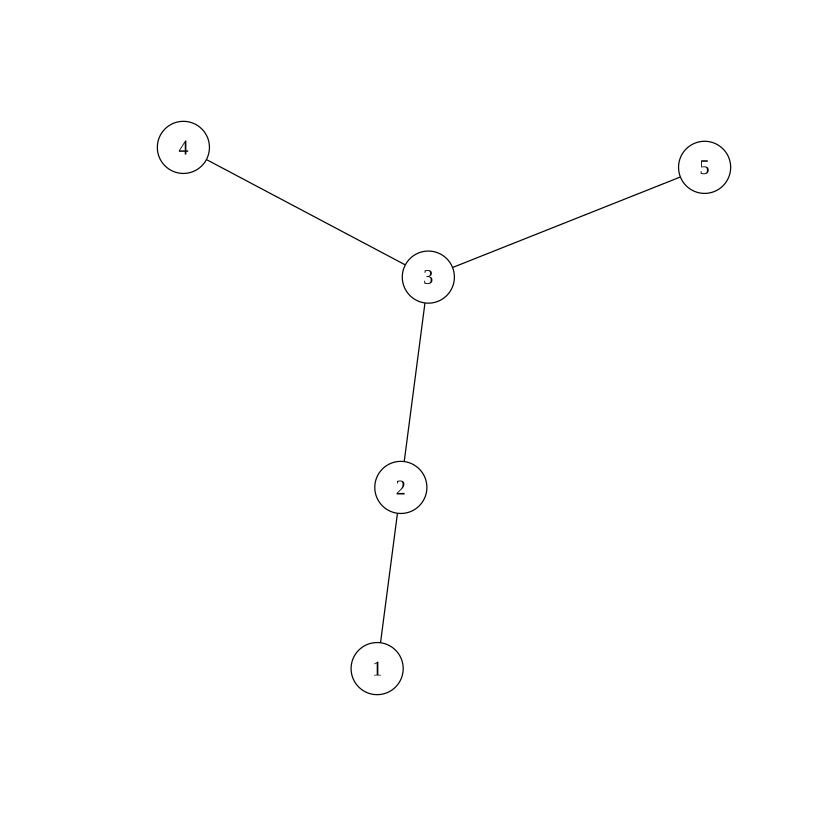

In [39]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex1.R")


We now have an undirected graph with 5 vertices and 4 edges. 
Vertex and edge IDs are **always** contiguous, so if you delete a vertex all subsequent vertices will be renumbered. 
When a vertex is renumbered, edges are not renumbered, but their source and target vertices will be.
Let's use `delete_vertices()` and `delete_edges()` to perform these operations.

In [40]:
g2

IGRAPH e23cf32 U--- 5 4 -- 
+ edges from e23cf32:
[1] 1--2 2--3 3--4 3--5

In [41]:
edge_id_to_delete <- get_edge_ids(g2, c(2, 3))
edge_id_to_delete

[1] 2

In [42]:
g2 <- delete_edges(g2, edge_id_to_delete)
g2

IGRAPH 8a438d8 U--- 5 3 -- 
+ edges from 8a438d8:
[1] 1--2 3--4 3--5

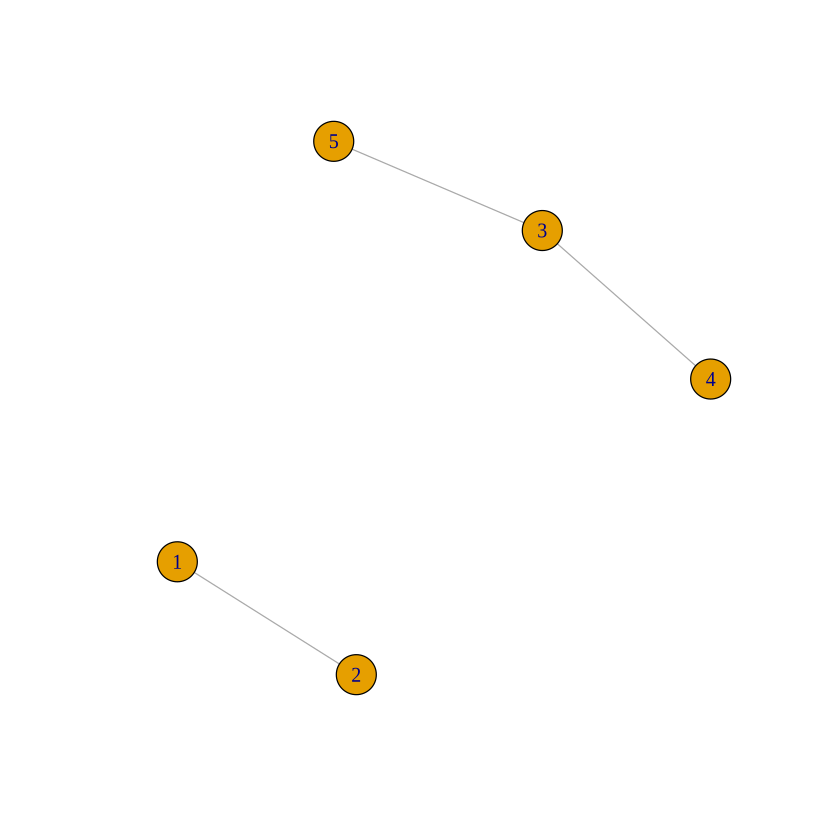

In [43]:
plot(g2)

## Creating non-simple Graphs - Edge properties
As we have seen, we can add different attributes to edges and nodes to enrich the information contained in the network. 
Usually much information can be incuding regarding the "interaction" between a couple of nodes. 
The most frequent examples are direction and weigth.


### Directed graphs
Unless otherwise specified, we assume graph edges are undirected -- they are symmetric and go both ways. 
But some relationships, e.g. predator-prey relationships, are asymmetric and best represented as directed graphs. 
In igraph we can make a directed graph by indicating in the construction that edges are NOT simmetric. 
Let's create a **Directed graph**

In [47]:
edges <- c(
  1, 2,
  1, 3,
  2, 3,
  2, 4,
  3, 4,
  3, 5,
  4, 5,
  4, 6,
  5, 6,
  6, 3
)

# Create the directed graph
dg <- make_graph(edges = edges, directed = TRUE)

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h3> Exercise 2</h3>
Create the directed graph corresponding to this simple network and plot it

![title](./images/figure2.jpg)
</div>

In [21]:
# write your code here and run it ################
#g3<-

```r
 g3 <- graph(
  edges = c(
    "plant", "snail",
    "plant", "caterpillar",
    "plant", "rabbit",
    "snail", "lizard",
    "caterpillar", "lizard"
  ),
  directed = TRUE
)
plot(g3,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",vertex.size=20) 
```

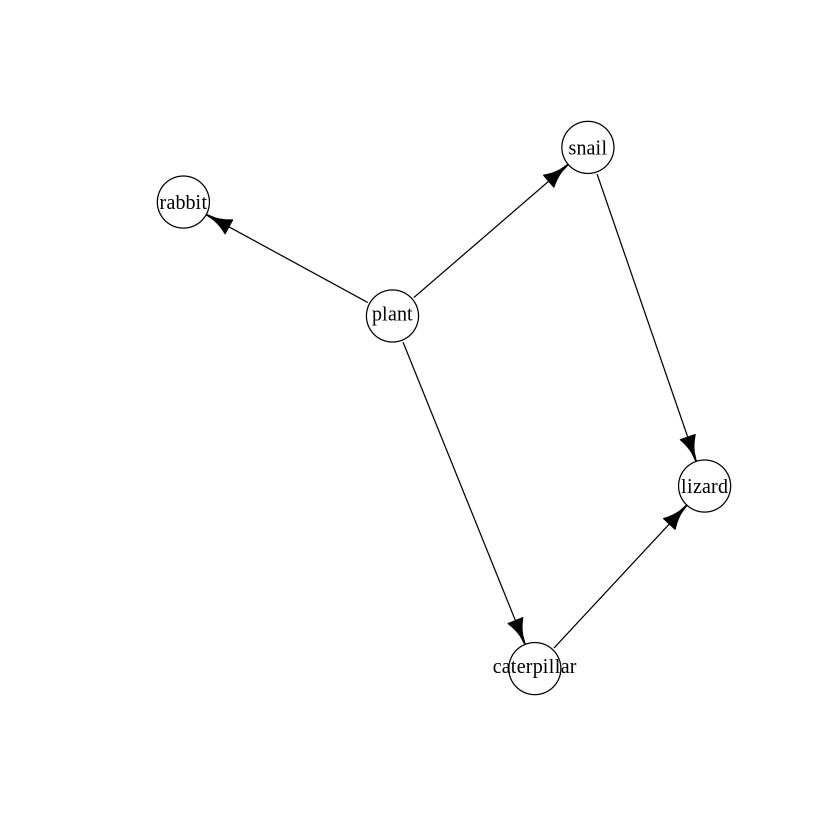

In [48]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex2.R")
#source("./snippets/ex1.R")

### Weighted graphs
We can add further information to the edges between nodes. Including the weigth of the interaction is very frequent. We can create a weighted network by adding the `ẁeigth` attribute to the edges in the network 


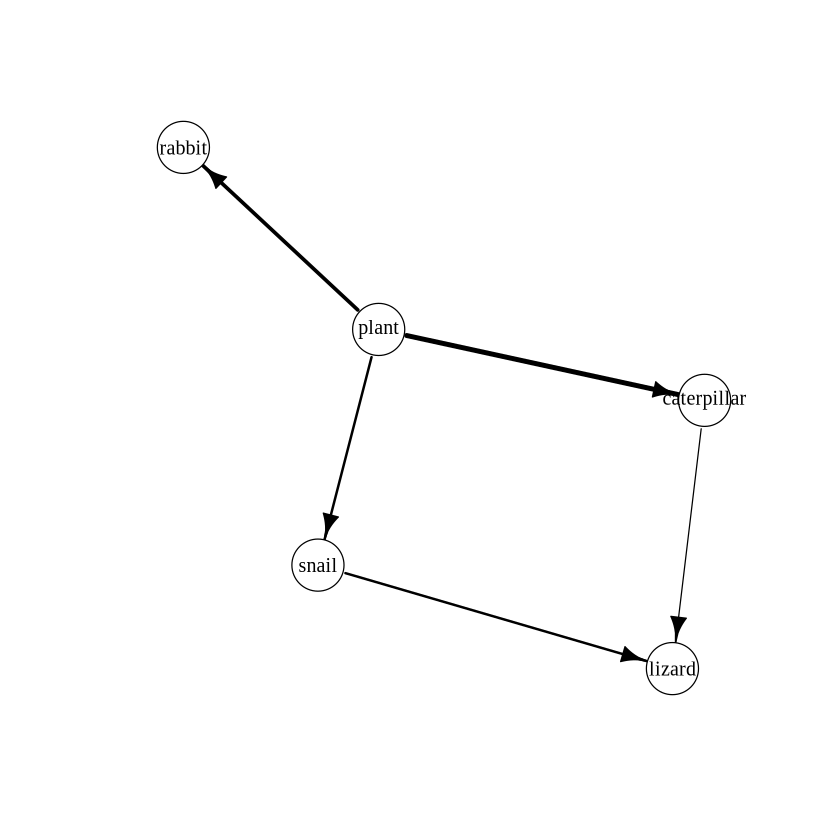

In [178]:
E(g3)$weight <- c(2, 4, 3, 2, 1)
plot(g3,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",edge.width = E(g3)$weight,vertex.size=20) 

## Creating non-simple Graphs - Node properties
In some cases we have different clases of nodes, for example plants and pollinators, or seed and dispersers. In this case the interactions only take place between nodes of different sets. These types of networks are called **bipartite networks** (because we have two different types of nodes), or multipartite networks if we have more than two different sets. Now, the attribute belongs to the **node**, not to the link. 

### Bipartite graphs
This type of networks are very frequent in ecology. While *igraph* does not have a dedicated bipartite graph class, the normal graph classes can be used to represent bipartite graphs. However, you have to keep track of which set each node belongs to, and make sure that there is no edge between nodes of the same set. The convention used in *igraph* is to use a node attribute named `type` with values TRUE or FALSE to identify the sets each node belongs to. This convention is not enforced in the code of *igraph* functions, it’s only a recommendation. Let's see how we can create a bipartite network using *igraph*.

In [3]:
B <- make_empty_graph(directed=FALSE) + vertices(c("P1","P2","P3","P4", "A1","A2","A3","A4","A5")) #two plants and three animals
V(B)$type <- c(TRUE, TRUE, TRUE, TRUE, FALSE, FALSE, FALSE, FALSE, FALSE) #plants have type TRUE (bottom set) and animals type FALSE (upper set). We NEED to specify it
B <- add_edges(B,c("P1","A1",  "P1","A2", "P1","A3", "P2","A2", "P2","A3",  "P2","A5", "P3","A2", "P3","A4", "P3","A5", "P4","A5"))
is_bipartite(B)

[1] TRUE

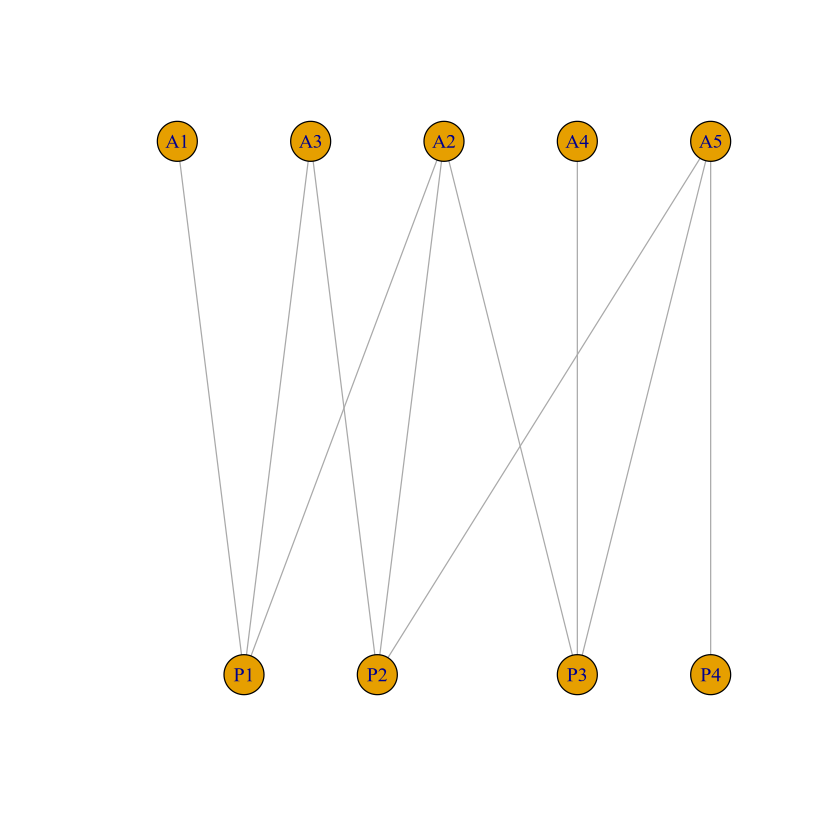

In [4]:
plot(B, layout = layout_as_bipartite)

#### Obtaining the bipartite sets
To retrieve the two sets, we just have to filter nodes with type==FALSE (top set), and type==TRUE (bottom set)

In [5]:
top_nodes <- V(B)$name[V(B)$type == FALSE] #animals
bottom_nodes <- V(B)$name[V(B)$type == TRUE] #plants

In [6]:
top_nodes

[1] "A1" "A2" "A3" "A4" "A5"

#### Bipartite projections
One of the most frequent uses of weighted networks is obtaining the weighted one-mode projections of bipartite networks. 

*igraph* has the function `bipartite_projection(g)`to obtain the one-mode projection of bipartite networks. 
These unipartite networks tell us how many shared partners each animal/plant has with the other rest of species in its same guild. 
Let's see how it works

In [7]:
proj <- bipartite_projection(B)
B_animals <- proj$proj1 #type==FALSE
B_plants  <- proj$proj2 #type==TRUE

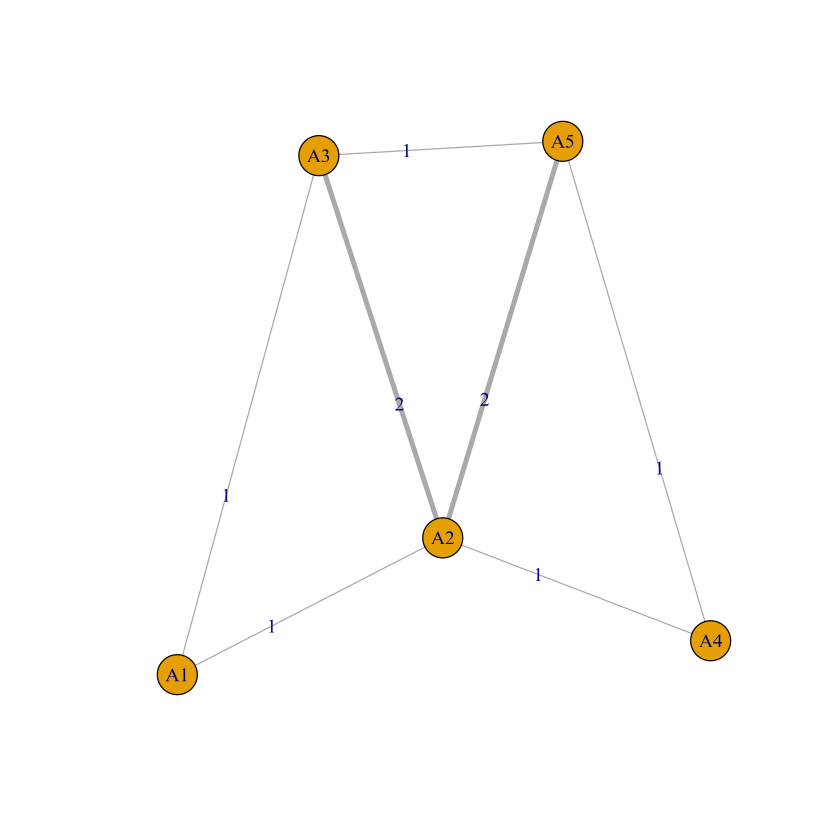

In [8]:
plot(B_animals, edge.width = E(B_animals)$weight^2,edge.label = E(B_animals)$weight)

Now let's try one with node attributes too, like a bipartite network

## Network representations

We have seen only the *graph* representation of the networks, but that is not the only way in which we can represent the interaction network. There are three ways in which interactions can be stored:
- graph  
- matrix  
- interaction list

### Networks as Dataframes - Matrix representation

The information that we have stored in the graph can, most times, be also stored in a dataframe. In these dataframes each row and each column represent one species, and the cell value represents the value of the intearction between them. Let's see how we can move from one format to another with some examples

#### Adjacency matrix

The adjacency matrix is a square matrix of dimension NxN (it has as many rows and columns as species), and contains the information of all the possible pairwise interaction among all the species in the community. Each element $A_{ij}$ represents the effect of $i$ over $j$, and are equal to $0$ when there is no interaction between $i$ and $j$, and different from 0 when there is an interaction. For those elements that are not zero, if the network is **unweighted** they will be all equal to 1, and if the networks is **weighted** they will be a number representing the intensity or frequency of the interaction. 

Let's see how we can obtain the adjacency matrices from unipartite graphs (where all nodes are of the same tyoe and can be connected among them).

In [198]:
#unweighted example
A1 <- as.matrix(as_adjacency_matrix(g3))
A1
rowSums(A1)
colSums(A1)

,plant,snail,caterpillar,rabbit,lizard
plant,0,1,1,1,0
snail,0,0,0,0,1
caterpillar,0,0,0,0,1
rabbit,0,0,0,0,0
lizard,0,0,0,0,0


plant       snail caterpillar      rabbit      lizard 
          3           1           1           0           0

plant       snail caterpillar      rabbit      lizard 
          0           1           1           1           2

In [199]:
#weighted example
A2 <- as.matrix(as_adjacency_matrix(g3, attr = "weight")) #the attribute weight must be defined before and contain the information
A2


,plant,snail,caterpillar,rabbit,lizard
plant,0,2,4,3,0
snail,0,0,0,0,2
caterpillar,0,0,0,0,1
rabbit,0,0,0,0,0
lizard,0,0,0,0,0


Now let's see the adjacency matrix of a plant-animal mutualistic network. Remember that the adjacency includes ALL pairwise interactions

In [200]:
A3 <- as.matrix(as_adjacency_matrix(B))
A3

,P1,P2,P3,P4,A1,A2,A3,A4,A5
P1,0,0,0,0,1,1,1,0,0
P2,0,0,0,0,0,1,1,0,1
P3,0,0,0,0,0,1,0,1,1
P4,0,0,0,0,0,0,0,0,1
A1,1,0,0,0,0,0,0,0,0
A2,1,1,1,0,0,0,0,0,0
A3,1,1,0,0,0,0,0,0,0
A4,0,0,1,0,0,0,0,0,0
A5,0,1,1,1,0,0,0,0,0


#### Incidence matrix

As you have jsut seen the natural way to encode the matrix information in bipartite networks is to just focus on part of the adjacency matrix, a subselection with dimension $N_{P}xN_{A}$. This matrix is called the incidence matrix, where plants appear in rows and animals in columns. We can generate the incidence matrix with the function `as_incidence_matrix(g)`

In [202]:
#unweighted networks
M1 <- t(as_incidence_matrix(B))
M1
rowSums(M1)
colSums(M1)

,A1,A2,A3,A4,A5
P1,1,1,1,0,0
P2,0,1,1,0,1
P3,0,1,0,1,1
P4,0,0,0,0,1


P1 P2 P3 P4 
 3  3  3  1

A1 A2 A3 A4 A5 
 1  3  2  1  3

In [197]:
#if we had frequencies as weight
#M <- t(as_incidence_matrix(B),attr = "weight")

We have seen how we can go from Graph to Dataframe, but we can also go from Dataframe to Graph format. 
In fact, this is very usefull to read networks from files as the adjacency and incidence matrices are the most frequent way in which interaction networks are shared. 

Let's see how we can go from a Dataframe to a Graph format

### Graph from Adjacency matrices

Remember the adjacency matrix of the simple foodweb we saw before. We can construct a graph representation like this:

In [207]:
A1

,plant,snail,caterpillar,rabbit,lizard
plant,0,1,1,1,0
snail,0,0,0,0,1
caterpillar,0,0,0,0,1
rabbit,0,0,0,0,0
lizard,0,0,0,0,0


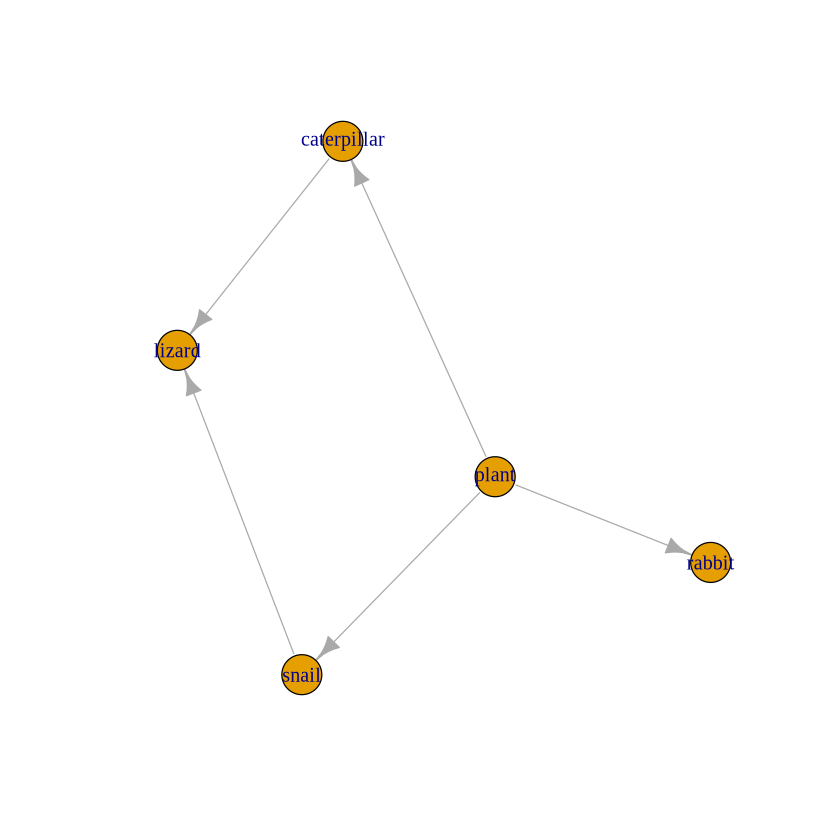

In [208]:
g1 <- graph_from_adjacency_matrix(
  A1,
  mode = "directed",   # or "undirected"
  weighted = FALSE,     # FALSE if binary
  diag = FALSE         # ignore self-loops
)
plot(g1)

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 3</h3>
Create the directed graph corresponding to adjacency matrix A2, and plot it


In [210]:
A2

,plant,snail,caterpillar,rabbit,lizard
plant,0,2,4,3,0
snail,0,0,0,0,2
caterpillar,0,0,0,0,1
rabbit,0,0,0,0,0
lizard,0,0,0,0,0


```r
 g2 <- graph_from_adjacency_matrix(
  A2,
  mode = "directed",   # or "undirected"
  weighted = TRUE,     # FALSE if binary
  diag = FALSE         # ignore self-loops
)
plot(g2,edge.width = E(g2)$weight)
 
```

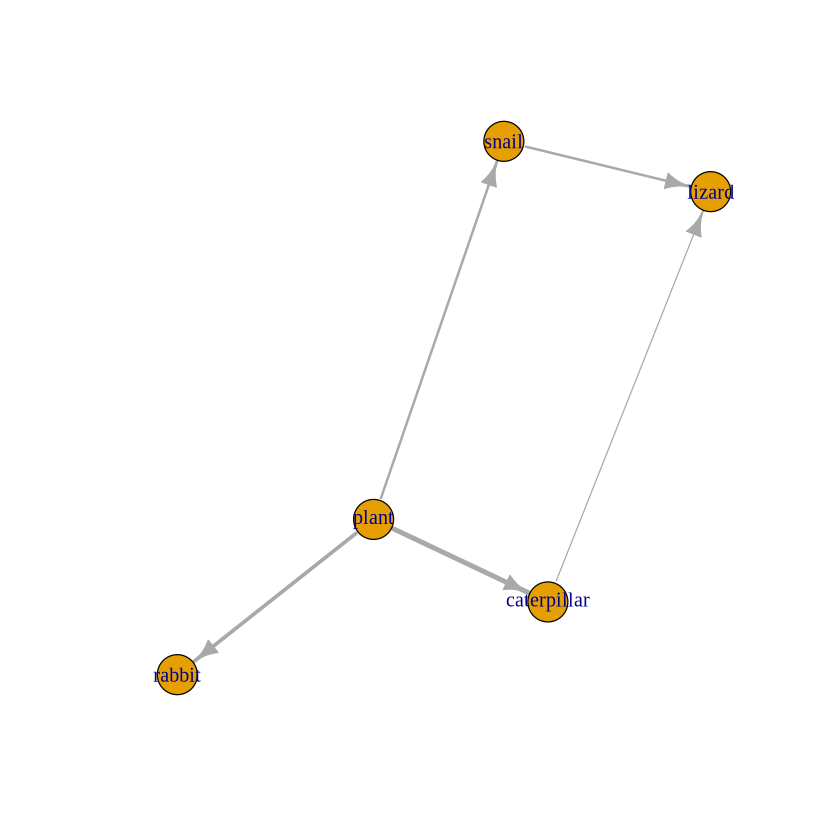

In [212]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex3.R")

### Graph from Incidence matrices

Remeber the matrix representation of the incidence matrix of the plant-animal mutualistic network we saw. We can create the graph representation as follows

In [214]:
M1

,A1,A2,A3,A4,A5
P1,1,1,1,0,0
P2,0,1,1,0,1
P3,0,1,0,1,1
P4,0,0,0,0,1


In [223]:
B1 <- graph_from_biadjacency_matrix(t(M1)) #we use the traspose because FALSE nodes appear as rows in the amtrix, but as upper level nodes in the bipartite graph.
is_bipartite(B1)

[1] TRUE

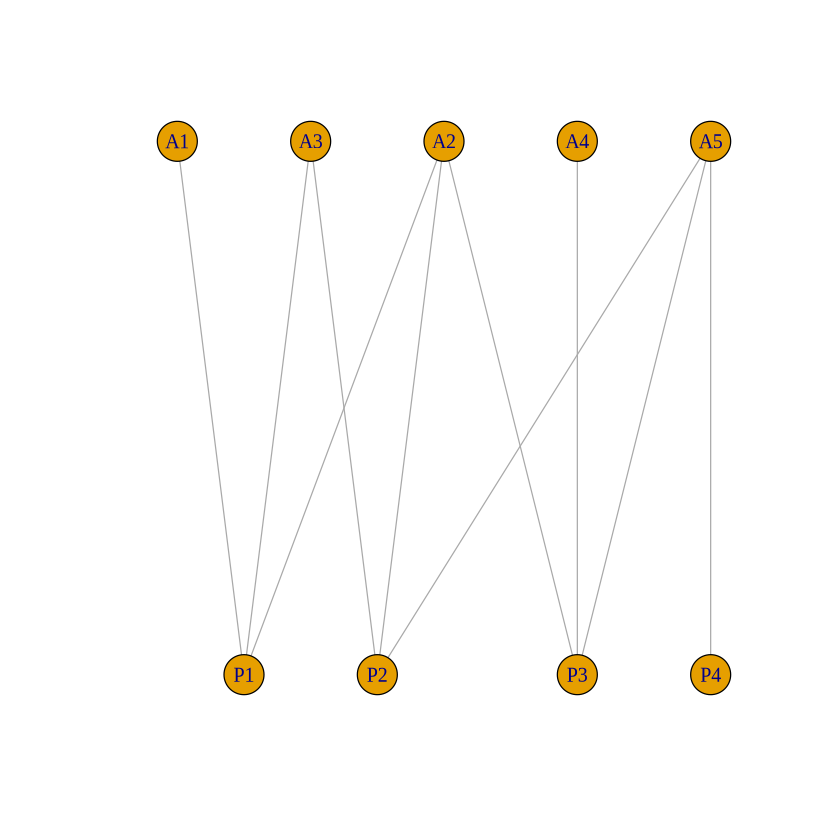

In [222]:
plot(B1, layout = layout_as_bipartite)

## Reading networks from adjaceny and incidence matrix files

As most networks are shared in these formats, the most comon way to import networks into your code will be by loading the csv as a dataframe and the converting that dataframe in a graph.
Let's see how we can import some real networks in here.

### Unipartite networks from adjacency matrices

Networks with only one type of nodes can be read from the $NxN$ Adjacency matrix ($A$) like this: 

*Note that you need a csv where the first row and column contains the names of the species. You should allways check that the structure matches what you expect*

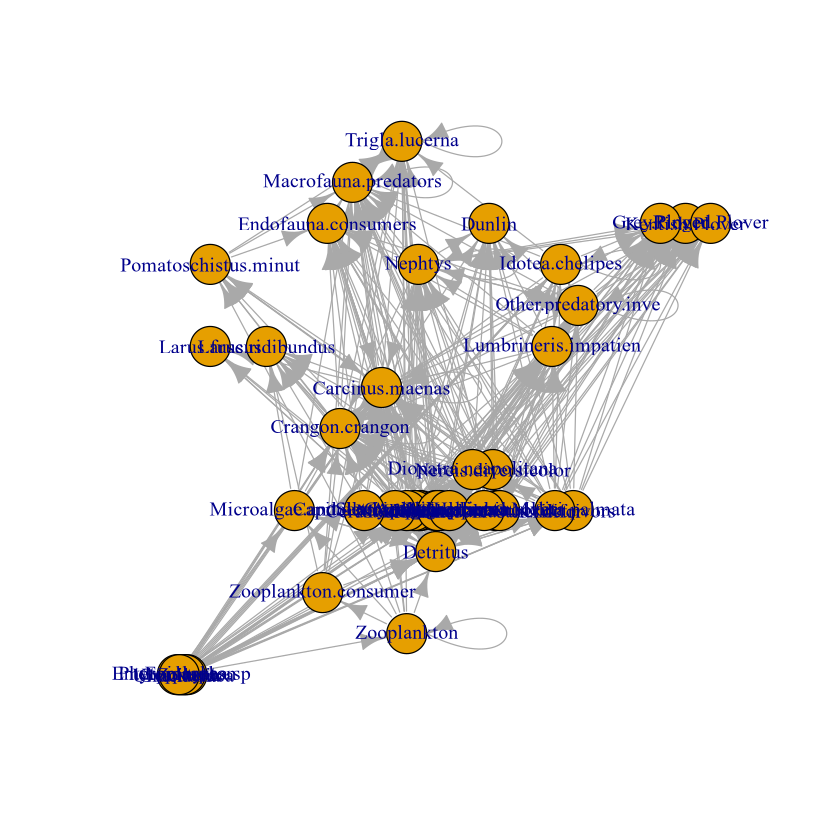

In [41]:
# Read the foodweb from the Mondego Estuary 
FW_Afilename<-"./Data/Mondego_adjacency.csv"
df <- read.csv(FW_Afilename, row.names = 1)
A <- as.matrix(df)
FW <- graph_from_adjacency_matrix(
  A,
  mode = "directed",   # or "undirected"
  weighted = TRUE,     # FALSE if binary
)
plot_as_flux(FW)

### Bipartite networks from Incidence matrices

Bipartite networks of mutualism can be read from the $N_p x N_A$ Incidence matrix ($I$) like this. 

*Again, note that the first row are the animal names and the first column the plant names.You should allways check that the structure matches what you expect*

[1] TRUE

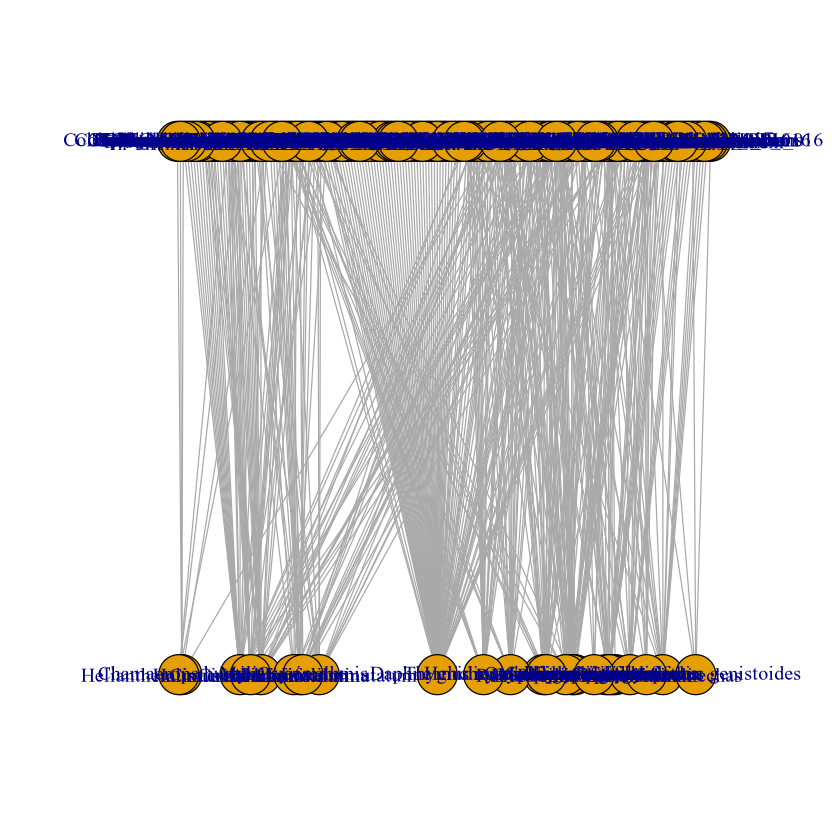

In [32]:
# Read the polination network from
B_Ifilename <- "./Data/Herrera_Donana_incidence.csv"
df <- read.csv(B_Ifilename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))
is_bipartite(B)
plot(B, layout = layout_as_bipartite)

## Networks as Dataframes - Interaction list

While the matrix form is the most common way to store information, is not the most efficient. When networks are large the matrix form stores a lot of 0s that are not relly needed. There is another format in which interactions can be stored, which is much more efficient for large networks: interaction lists. 

Interaction lists only contain the itneractions that exists in the network, and can also be stored in a dataframe where the first column represent the source node (from), and the second column the sink node (to), with an optional third column that contains information about the link, like for example the weigth or the sign of the interaction. 


### Unipartite networks

Let's see how the itneraction list of the Mondego foodweb looks like

In [5]:
FW_Ifilename <-"./Data/Mondego_ilist.csv"
FW_Ilist <- read.csv(FW_Ifilename)
head(FW_Ilist)

,from,to,weight
,<chr>,<chr>,<dbl>
1,Phytoplankton,Zooplankton,22.97171
2,Phytoplankton,Scrobicularia plana,4.40037
3,Phytoplankton,Cerastoderma edule,18.79548
4,Phytoplankton,Modiolus,0.03300
5,Phytoplankton,Microalgae and detri,1.76904
6,Phytoplankton,Detritus,14.19040


One can create a directed graph from an interaction list with `

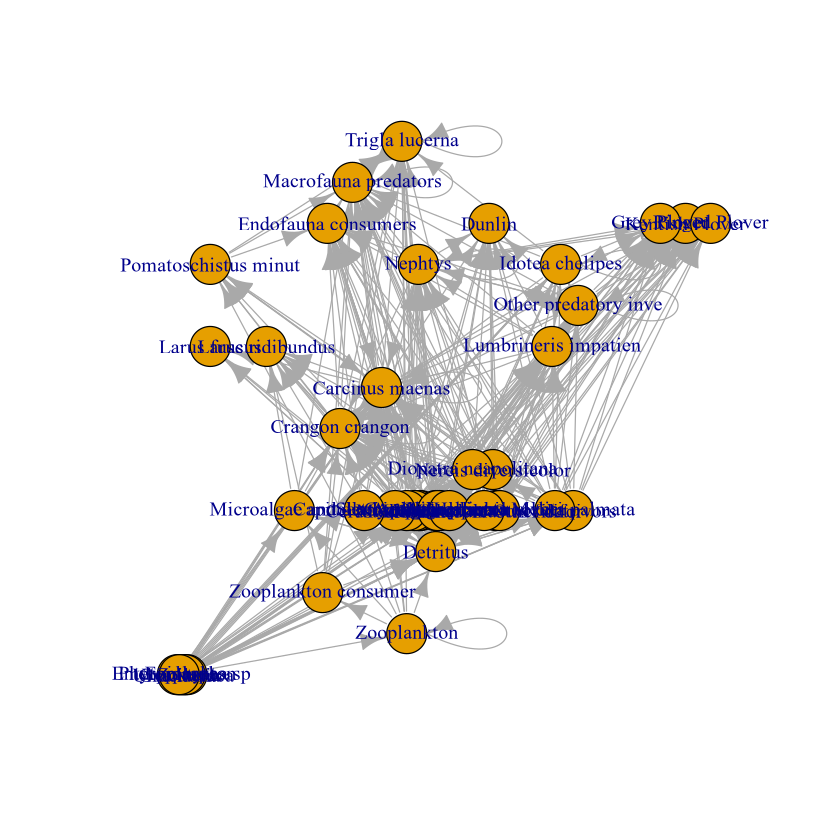

In [6]:
FW2 <- graph_from_data_frame(FW_Ilist,directed = TRUE)
plot_as_flux(FW2)
#E(FW2)$weight

### Bipartite networks

It is not common to find mutualistic networks in this format, but it can also be used. The important point here is that not all nodes appear in the two columns, rather plants will be in column one, and animals in column two, 

In [33]:
B_Ifilename<-"./Data/Herrera_Donana_ilist.csv"
B_Ilist <- read.csv(B_Ifilename)
B2 <- graph_from_data_frame(B_Ilist, directed = FALSE)
#however igraph does not directly understands this is a bipartite graph, so we need to specify the node sets
V(B2)$type <- V(B2)$name %in% B_Ilist$plant_sp #Planst as type==TRUE
is_bipartite(B2)

[1] TRUE

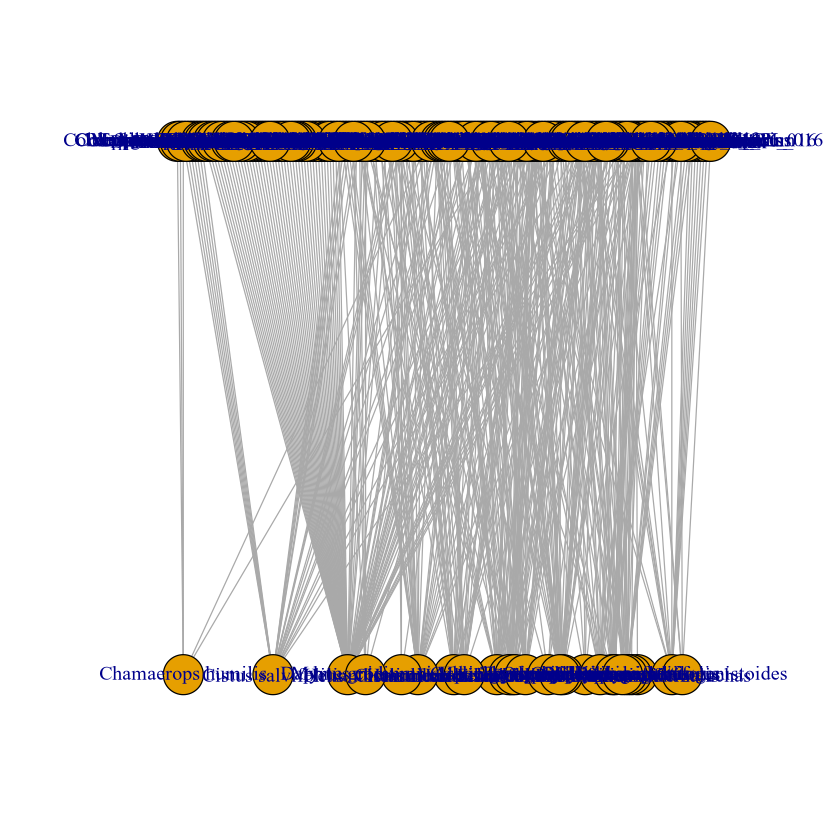

In [42]:
plot(B2, layout = layout_as_bipartite)

## Save to file
Once you are done creating your network, probably you will want to save it. 

The most useful format for networks with attributes is **GML**, as it allows to keep these attributes, but is readeable. 
Let's see how it works, and how the information is stored. 

You can save (and load) netowkrs using this format like this:

Unipartite networks:

In [11]:
filename<-"Output/FW.gml"
write_graph(FW, filename, format = "gml")

In [12]:
#let's read to see how it looks like
FW3 <- read_graph(filename, format = "gml")

And Bipartite netowkrs too: (and they conserve the bipartite information)

In [13]:
filename<-"Output/B.gml"
write_graph(B, filename, format = "gml")
B3 <- read_graph(filename, format = "gml")
is_bipartite(B3)

Warning message in write.graph.gml(graph, file, ...):
“At vendor/cigraph/src/io/gml.c:1210 : The boolean vertex attribute 'type' was converted to numeric.”


[1] TRUE

It is possible also to save networks in **csv**, either as adjacency matrices or interaction lists, but these can loose some properties.

Exporting the adjacency matrix and the interaction list of a directed network:

In [ ]:
filename<-"./Output/FW_adjacency.csv"
A <- as.matrix(as_adjacency_matrix(FW, attr = "weight")) #one goes from graph to adjacency matrix
write.csv(A, filename) #and exports the adjacency matrix

In [37]:
filename<-"./Output/FW_ilist.csv"
FW_Ilist <- igraph::as_data_frame(FW)
write.csv(FW_Ilist, filename,row.names = FALSE) #and exports the adjacency matrix

Exporting the incidence matrix a bipartite network:

In [23]:
filename<-"./Output/B_incidence.csv"
I <- as.matrix(as_biadjacency_matrix(B))
write.csv(t(I), filename) #exports the incidence matrix (use transpose to have plants as rows!)

and the interaction list:

In [38]:
filename <- "./Output/B_ilist.csv"
Ilist <- igraph::as_data_frame(B2)
colnames(Ilist)[1:2] <- c("plant_sp", "pol_sp")
write.csv(Ilist, filename,row.names = FALSE) #exports the incidence matrix (use transpose to have plants as rows!)

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 4 & 5 </h3>
Creathe the graph of the foodweb of the St. Marks stuary, and the mutualistic network from Rio Blaco from the provided files

</div>

In [ ]:
# Foodweb: continue your code here
FW_filename<- "./Data/FW_st_marks.csv"

```r
 FW_Ilist <- read.csv(FW_filename)
FW <- graph_from_data_frame(FW_Ilist,directed = TRUE)
plot_as_flux(FW,edge.width = E(FW)$weight*0.05) 
```

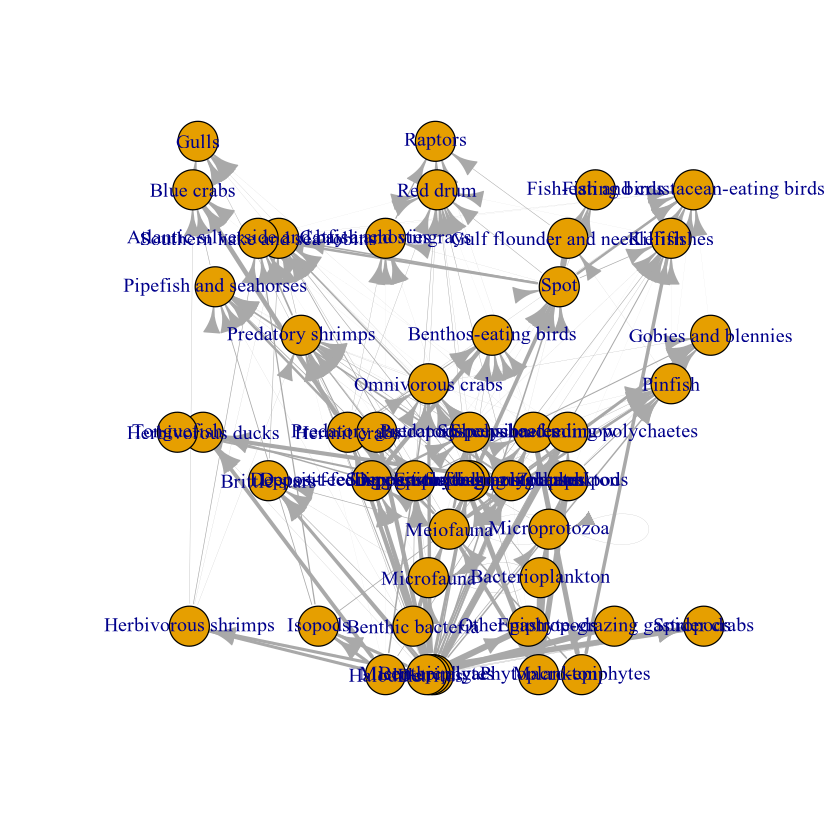

In [141]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex4.R")



In [147]:
# Pollination: continue your code here
P_Filename<-"./Data/Medan_Rio_Blanco.csv"

```r
 df <- read.csv(P_Filename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))
is_bipartite(B)
plot(B, layout = layout_as_bipartite) 
```

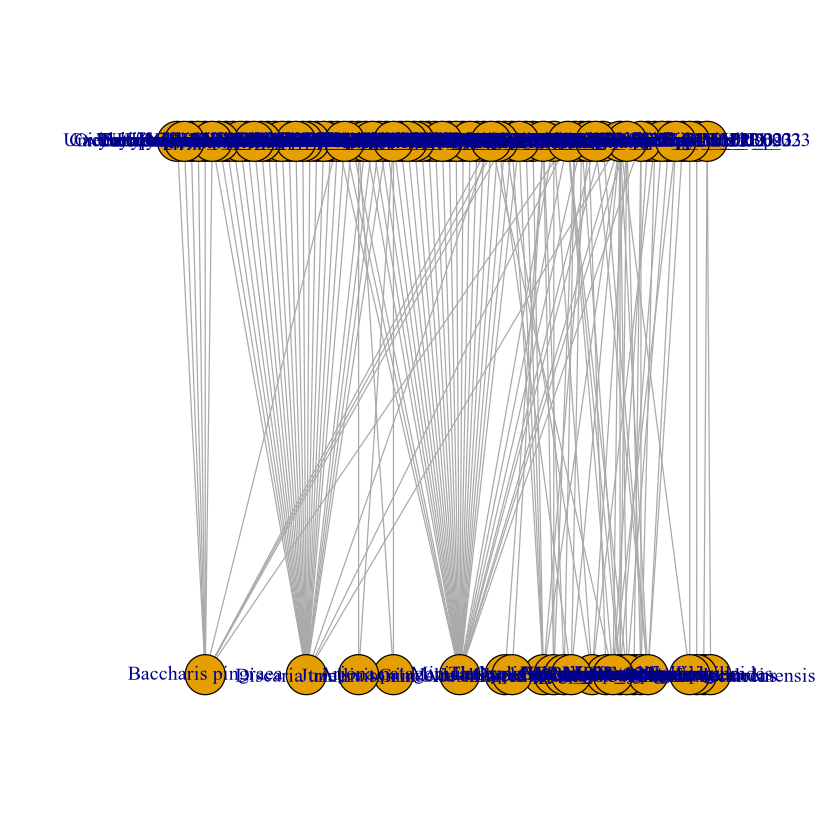

In [149]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex5.R")

# Lesson 1B 

Now let's continue with basic functions of igraph to access graph elements, and basic properties:
- Obtaining nodes and edges
- Checking if node/edge exists
- Counting nodes and edges
- Degree of nodes

Now that we saw how one can create or load netwrosk in R, let's start to explore them. 

## Obtaining nodes and links in a network

We can get the number of nodes and edges in a graph using the `vcount(g)` and `ecount(g)` functions. 

We can get all the nodes(vertices) in a network using `V(g)` and all the links(edges) using `E(g)`.


In [151]:
# Example: obtain all the nodes in the Mondego foodweb
FW_Afilename<-"./Data/Mondego_adjacency.csv"
df <- read.csv(FW_Afilename, row.names = 1)
A <- as.matrix(df)
FW <- graph_from_adjacency_matrix(
  A,
  mode = "directed",   # or "undirected"
  weighted = TRUE,     # FALSE if binary
)
FW

IGRAPH 3f557d8 DNW- 43 348 -- 
+ attr: name (v/c), weight (e/n)
+ edges from 3f557d8 (vertex names):
 [1] Phytoplankton  ->Zooplankton          Phytoplankton  ->Scrobicularia.plana 
 [3] Phytoplankton  ->Cerastoderma.edule   Phytoplankton  ->Modiolus            
 [5] Phytoplankton  ->Microalgae.and.detri Phytoplankton  ->Detritus            
 [7] Enteromorpha.sp->Melita.palmata       Enteromorpha.sp->Ampithoe.ferox      
 [9] Enteromorpha.sp->Gibulla              Enteromorpha.sp->Littorina           
[11] Enteromorpha.sp->Idotea.chelipes      Enteromorpha.sp->Carcinus.maenas     
[13] Enteromorpha.sp->Crangon.crangon      Enteromorpha.sp->Detritus            
[15] Ulva.lactuca   ->Melita.palmata       Ulva.lactuca   ->Ampithoe.ferox      
+ ... omitted several edges

In [152]:
rowSums(A)
colSums(A)

Phytoplankton      Enteromorpha sp         Ulva lactuca 
           62.160000             6.120000             1.118101 
             Zostera            Epiphytes           Gracilaria 
          512.091300          1385.100125            48.242998 
         Zooplankton       Hydrobia ulvae       Melita palmata 
           17.866895           213.525025             2.359175 
      Ampithoe ferox              Gibulla            Littorina 
            4.108778             0.379025            14.932177 
   Cyathura carinata  Scrobicularia plana   Cerastoderma edule 
            0.341040            17.601478            75.181902 
            Modiolus       Amage adspersa   Capitella capitata 
            0.132000             0.055199             0.043200 
Heteromastus filifor          Oligochaeta      Other detrivors 
            4.392000             0.993511             5.220001 
             Nephtys Other predatory inve      Idotea chelipes 
            0.478400             2.432554             0.303999 
   Sphaeroma hookeri  Nereis diversicolor      Carcinus maenas 
            0.019000             9.696406            13.949227 
     Crangon crangon Lumbrineris impatien Diopatra neapolitana 
            1.586468             0.624001             0.251542 
Microalgae and detri Zooplankton consumer  Endofauna consumers 
            4.397328             0.934454             0.085200 
Macrofauna predators       Trigla lucerna Pomatoschistus minut 
            0.776208             0.056000             0.103758 
    Larus ridibundus         Larus fuscus       Kentish Plover 
            0.000408             0.000340             0.000068 
       Ringed Plover          Grey Plover               Dunlin 
            0.000068             0.000068             0.000068 
            Detritus 
          384.548924

Phytoplankton      Enteromorpha.sp         Ulva.lactuca 
            0.000000             0.000000             0.000000 
             Zostera            Epiphytes           Gracilaria 
            0.000000             0.000000             0.000000 
         Zooplankton       Hydrobia.ulvae       Melita.palmata 
           25.524123           355.875000             3.931959 
      Ampithoe.ferox              Gibulla            Littorina 
            6.847964             0.631708            37.330443 
   Cyathura.carinata  Scrobicularia.plana   Cerastoderma.edule 
            0.568400            29.335800           125.303180 
            Modiolus       Amage.adspersa   Capitella.capitata 
            0.220000             0.092000             0.072000 
Heteromastus.filifor          Oligochaeta      Other.detrivors 
            7.320000             1.655849             8.700001 
             Nephtys Other.predatory.inve      Idotea.chelipes 
            1.196001             6.081393             0.760000 
   Sphaeroma.hookeri  Nereis.diversicolor      Carcinus.maenas 
            0.047500            24.241015            34.873057 
     Crangon.crangon Lumbrineris.impatien Diopatra.neapolitana 
            3.966172             1.559998             0.628856 
Microalgae.and.detri Zooplankton.consumer  Endofauna.consumers 
           17.690400             2.493664             0.186001 
Macrofauna.predators       Trigla.lucerna Pomatoschistus.minut 
            2.593418             0.140000             0.259395 
    Larus.ridibundus         Larus.fuscus       Kentish.Plover 
            0.000577             0.000121             0.000239 
       Ringed.Plover          Grey.Plover               Dunlin 
            0.000239             0.000240             0.000240 
            Detritus 
         2092.081466

In [ ]:
# let's obtain the number of nodes and links
N=vcount(FW)
N
L=ecount(FW)
L

[1] 43

[1] 348

In [154]:
#lest obtain all the nodes
V(FW)

+ 43/43 vertices, named, from 3f557d8:
 [1] Phytoplankton        Enteromorpha.sp      Ulva.lactuca        
 [4] Zostera              Epiphytes            Gracilaria          
 [7] Zooplankton          Hydrobia.ulvae       Melita.palmata      
[10] Ampithoe.ferox       Gibulla              Littorina           
[13] Cyathura.carinata    Scrobicularia.plana  Cerastoderma.edule  
[16] Modiolus             Amage.adspersa       Capitella.capitata  
[19] Heteromastus.filifor Oligochaeta          Other.detrivors     
[22] Nephtys              Other.predatory.inve Idotea.chelipes     
[25] Sphaeroma.hookeri    Nereis.diversicolor  Carcinus.maenas     
[28] Crangon.crangon      Lumbrineris.impatien Diopatra.neapolitana
+ ... omitted several vertices

you can also access the attributes with "$" (if they exists)

In [155]:
V(FW)$name # for example the node names are an attribute

[1] "Phytoplankton"        "Enteromorpha.sp"      "Ulva.lactuca"        
 [4] "Zostera"              "Epiphytes"            "Gracilaria"          
 [7] "Zooplankton"          "Hydrobia.ulvae"       "Melita.palmata"      
[10] "Ampithoe.ferox"       "Gibulla"              "Littorina"           
[13] "Cyathura.carinata"    "Scrobicularia.plana"  "Cerastoderma.edule"  
[16] "Modiolus"             "Amage.adspersa"       "Capitella.capitata"  
[19] "Heteromastus.filifor" "Oligochaeta"          "Other.detrivors"     
[22] "Nephtys"              "Other.predatory.inve" "Idotea.chelipes"     
[25] "Sphaeroma.hookeri"    "Nereis.diversicolor"  "Carcinus.maenas"     
[28] "Crangon.crangon"      "Lumbrineris.impatien" "Diopatra.neapolitana"
[31] "Microalgae.and.detri" "Zooplankton.consumer" "Endofauna.consumers" 
[34] "Macrofauna.predators" "Trigla.lucerna"       "Pomatoschistus.minut"
[37] "Larus.ridibundus"     "Larus.fuscus"         "Kentish.Plover"      
[40] "Ringed.Plover"        "Grey.Plover"          "Dunlin"              
[43] "Detritus"

you can access **one particular node** either by its name, by its internal index, or by a condition 

In [156]:
#by name
V(FW)["Phytoplankton"]

#by internal index
V(FW)[1]

#by a condition
V(FW)[name %in% c("Phytoplankton", "Zooplankton")]

+ 1/43 vertex, named, from 3f557d8:
[1] Phytoplankton

+ 1/43 vertex, named, from 3f557d8:
[1] Phytoplankton

+ 2/43 vertices, named, from 3f557d8:
[1] Phytoplankton Zooplankton  

We can also obtain the edges of a network in a similar way

In [157]:
E(FW) #they are directed, notice the arrow pointing the direction of the interaction

+ 348/348 edges from 3f557d8 (vertex names):
 [1] Phytoplankton  ->Zooplankton          Phytoplankton  ->Scrobicularia.plana 
 [3] Phytoplankton  ->Cerastoderma.edule   Phytoplankton  ->Modiolus            
 [5] Phytoplankton  ->Microalgae.and.detri Phytoplankton  ->Detritus            
 [7] Enteromorpha.sp->Melita.palmata       Enteromorpha.sp->Ampithoe.ferox      
 [9] Enteromorpha.sp->Gibulla              Enteromorpha.sp->Littorina           
[11] Enteromorpha.sp->Idotea.chelipes      Enteromorpha.sp->Carcinus.maenas     
[13] Enteromorpha.sp->Crangon.crangon      Enteromorpha.sp->Detritus            
[15] Ulva.lactuca   ->Melita.palmata       Ulva.lactuca   ->Ampithoe.ferox      
[17] Ulva.lactuca   ->Gibulla              Ulva.lactuca   ->Littorina           
[19] Ulva.lactuca   ->Idotea.chelipes      Ulva.lactuca   ->Carcinus.maenas     
+ ... omitted several edges

And the attributes of the links as well

In [158]:
E(FW)$weight 

[1]   22.971710    4.400370   18.795480    0.033000    1.769040   14.190400
  [7]    0.393196    0.684796    0.063171    3.733044    0.076000    0.917436
 [13]    0.229992    0.022365    0.035388    0.061632    0.012634    0.746609
 [19]    0.003800    0.190644    0.019827    0.047567    0.228000  511.863300
 [25]  177.937500    2.752371    4.793575    0.347439   20.531740    0.114000
 [31]    0.009500 1178.614000    0.190000    1.312617    0.067411   46.672970
 [37]    2.552413    0.104730    0.186373    1.769040    2.493664    0.163795
 [43]    0.009715    0.224365   10.362800    0.359053    9.823225    4.573213
 [49]    0.007931    0.001814    0.056597    0.016166    0.015166    0.002211
 [55]    0.000013    0.000140    0.000060    0.000059    0.000077  198.669300
 [61]    0.004782    0.304283    0.209460    0.166546    0.001823    0.006289
 [67]    0.045499    0.008313    0.000004    0.000013    0.000030    0.000030
 [73]    1.612103    0.007173    0.572051    0.024255    0.279280    0.317230
 [79]    0.001823    0.006289    0.078864    0.000010    0.014007    0.000006
 [85]    0.000023    0.000051    0.000051    2.807665    0.006086    0.024918
 [91]    0.034910    0.003965    0.021772    0.000557    0.000003    0.286814
 [97]    0.060857    0.436588    0.104730    0.003965    0.003629    0.001858
[103]    0.000100   14.320450    0.060857    0.019827    0.015603    0.015166
[109]    0.000140    0.229447    0.023910    0.359053    0.582117    3.491003
[115]    0.317230    0.054612    0.006289    0.004088    0.054598    0.000840
[121]    0.000461    0.000014    0.000014    0.000012    0.000024    0.000003
[127]   12.707210    0.062167    0.499023    0.921711    5.550694    0.491707
[133]    0.021845    0.006289    0.009848    0.090997    0.001424    0.000030
[139]    0.000009    0.000023    0.000024    0.000001   67.526110    0.001196
[145]    0.009702    0.003965    0.001560    0.000186    0.003033    0.112358
[151]    0.001196    0.002434    0.003965    0.000557    0.000003    0.047044
[157]    0.000478    0.006982    0.000793    0.003121    0.000372    0.000030
[163]    0.031424    0.181719    0.821563    0.001520    0.097020    0.174550
[169]    0.027758    0.001560    0.026014    0.030332    0.000002    0.000008
[175]    0.000007    0.000006    3.029941    0.182570    0.001520    0.024255
[181]    0.069820    0.027758    0.007802    0.000186    0.000012    0.679588
[187]    0.223563    0.791135    0.001520    0.169784    0.314190    0.039654
[193]    0.001560    0.044020    0.033447    0.090997    0.000006    0.000013
[199]    0.000012    0.000011    3.510089    0.005978    0.018257    0.174550
[205]    0.007931    0.000743    0.015166    0.000001    0.000001    0.000001
[211]    0.000001    0.255771    0.186501    0.578137    0.002280    0.174550
[217]    0.023792    0.001560    0.018581    0.030332    0.000002    0.000012
[223]    0.000005    0.000005    1.416797    0.060857    0.008360    0.043619
[229]    0.001560    0.030332    0.000140    0.000001    0.159130    0.006086
[235]    0.003033    0.009881    0.050212    0.212998    3.491003    0.721699
[241]    0.033447    0.094030    0.002231    0.000025    0.000020    0.000059
[247]    0.000032    0.000037    5.090613    1.640771    0.154650    0.006318
[253]    0.831108    0.042572    0.000623    0.000006    0.000094    0.000016
[259]    0.000014    0.000015   11.273040    0.349100    0.007931    0.022298
[265]    0.303324    0.061057    0.009856    0.000006    0.832896    0.004782
[271]    0.121713    0.069820    0.015862    0.007804    0.009100    0.000001
[277]    0.000002    0.000002    0.000001    0.394914    0.005978    0.048685
[283]    0.034910    0.015862    0.000372    0.009100    0.000001    0.000002
[289]    0.000002    0.136630    0.349100    0.019827    0.248726    0.000003
[295]    3.779672    0.174550    0.047585    0.181994    0.009803    0.000003
[301]    0.520519    0.034910    0.003033    0.047257    0.057632    0.001260
[307]    0.717316    0.0

One can see all the attributes that are present in the graph summary:

In [159]:
FW

IGRAPH 3f557d8 DNW- 43 348 -- 
+ attr: name (v/c), weight (e/n)
+ edges from 3f557d8 (vertex names):
 [1] Phytoplankton  ->Zooplankton          Phytoplankton  ->Scrobicularia.plana 
 [3] Phytoplankton  ->Cerastoderma.edule   Phytoplankton  ->Modiolus            
 [5] Phytoplankton  ->Microalgae.and.detri Phytoplankton  ->Detritus            
 [7] Enteromorpha.sp->Melita.palmata       Enteromorpha.sp->Ampithoe.ferox      
 [9] Enteromorpha.sp->Gibulla              Enteromorpha.sp->Littorina           
[11] Enteromorpha.sp->Idotea.chelipes      Enteromorpha.sp->Carcinus.maenas     
[13] Enteromorpha.sp->Crangon.crangon      Enteromorpha.sp->Detritus            
[15] Ulva.lactuca   ->Melita.palmata       Ulva.lactuca   ->Ampithoe.ferox      
+ ... omitted several edges

## Global and Local functions

Some functions take the full graph as variable, like `E(G)`, and return one value for the entire graph. 

However, other functions apply only to a node or a link. These are local functions and take more variables. 

### Neighbours
For example the function that returns the neighbours of a node `neighbors(g,v)`

In [160]:
my_node=V(FW)[1] #the third node
neighbors(FW, my_node, mode = "all")


+ 6/43 vertices, named, from 3f557d8:
[1] Zooplankton          Scrobicularia.plana  Cerastoderma.edule  
[4] Modiolus             Microalgae.and.detri Detritus            

> Note: Because this is a **directed** network we have in-neighbours, and out-neighbours!

In [161]:
neighbors(FW, my_node, mode = "out")
neighbors(FW, my_node, mode = "in")

+ 6/43 vertices, named, from 3f557d8:
[1] Zooplankton          Scrobicularia.plana  Cerastoderma.edule  
[4] Modiolus             Microalgae.and.detri Detritus            

+ 0/43 vertices, named, from 3f557d8:

### Node degree

One of the most important questions we can ask about a node in a graph is how many other nodes it connects to. Using the `neighbors()` function from above, we could formulate this question as so: how many neighbours does my node have?

In [162]:
length(neighbors(FW, my_node, mode = "all"))

[1] 6

but this is such a common task that *igraph** provides us a graph method to do this in a much clearer way:

In [169]:
igraph::degree(FW, my_node)

Phytoplankton 
            6

> In **directed networks** we have `in-degree()` (edges **entering** the node) and `out degree()` (edges **exiting** the node). The function `degree()` in directed networks returns the sum of the in and out connections.

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h3> Exercise 6</h3>
Load the foodweb of the St Marks Estuary and answer these questions:
    
- How many species are in the network?
- What is the species that has more predators? 
- What is the species that has a more varied diet? 
- What are the species that feed on the most generalist predator? 
    
![title](./images/figure5.png)
</div>


In [ ]:
#your code here (remember you already loaded the network before, look how it is done)

In [6]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex6.R")

```r
 FW_filename<- "./Data/FW_st_marks.csv"
FW_Ilist <- read.csv(FW_filename)
FW <- graph_from_data_frame(FW_Ilist,directed = TRUE)

#how many species in the network?
N<-vcount(FW)
cat(sprintf("There are %d species\n", N))

#species with more predators (more out-neighbours)
#build a dataframe with the degree of each node
deg_df <- data.frame(
  species = names(igraph::degree(FW)),
  degree  = igraph::degree(FW),
  indeg   = igraph::degree(FW, mode = "in"),
  outdeg  = igraph::degree(FW, mode = "out"),
  row.names = NULL
)
#species with maximum out degree
most_preyed=deg_df$species[deg_df$outdeg == max(deg_df$outdeg)]
cat(sprintf("The most consumed prey is %s\n", most_preyed))


#now the species with larger in-connectivity
generalist_predator=deg_df$species[deg_df$indeg == max(deg_df$indeg)]
cat(sprintf("The most generalist species is %s\n", generalist_predator))

#who is preying on it?
predators=neighbors(FW, generalist_predator[1], mode = "out")
cat(sprintf("The predators of the firs

<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h3> Exercise 6B</h3>
Load the pollination network of Rio Blanco, and answer these questions:

- How many plant and pollinator species are in the network?
- What is the most generalist polinator?
- How many specialized plants arethere? (k=1)
- How many pollinators are shared between the two most generalist plants?

In [7]:
#your code here (remember you already loaded the network before, look how it is done)

In [68]:
#read and load network to graph
P_Filename<-"./Data/Medan_Rio_Blanco.csv"
df <- read.csv(P_Filename, row.names = 1)
I <- as.matrix(df)
B <- graph_from_biadjacency_matrix(t(I))

#1) number of plants and pollinators
#plants are stored in rows and polliantor sin collumns
Np <- nrow(I)
Na <- ncol(I)
cat(sprintf("There are %d plant species and %d pollinator species\n", Np, Na))

#if from the graph, one can do 
tt<-table(V(B)$type)
Np <- as.numeric(tt["TRUE"])
Na <- as.numeric(tt["FALSE"])

#2) most generalist pollinator
polls <- V(B)[type == FALSE]
kA <- igraph::degree(B, v= polls)
Pgen=polls$name[kA==max(kA)]
cat(sprintf("Most generalist pollinator is %s\n", Pgen))

#3)plants with degree 1
plants <- V(B)[type == TRUE]
kP <- igraph::degree(B, v= plants)
specialized_plants<-plants$name[kP == 1]
NP_s=length((specialized_plants))
cat(sprintf("There are %d plant species with only one mutualistic partner\n", NP_s))


#4) shared pollinators between generalist plants
#All the shared pollinators
Aproj <- igraph::bipartite_projection(B, which = "true", multiplicity = TRUE)
M <- igraph::as_adjacency_matrix(Aproj, attr = "weight", sparse = FALSE)
top2 <- plants$name[order(kP, decreasing = TRUE)][1:2]
shared_p <- M[top2[1], top2[2]]
cat(sprintf("The two most specialized plants share %d pollinators\n", shared_p))

There are 23 plant species and 72 pollinator species


Most generalist pollinator is Copestylum.aricia
There are 7 plant species with only one mutualistic partner
The two most specialized plants share 10 pollinators
